# COMP6012: Neural Networks and Statistical Machine Learning
## Default Task 1 — Transfer Learning for Image Classification
### Dataset: Oxford 102 Flowers
---
**Student Name:** Alan Michael Bello  |  **Student ID:** 22504704
**Date:** 20th May 2026  
**Unit:** COMP6012
Neural Networks and Statistical Machine Learning  
**Platform:** Google Colab

---
| Part | Coverage |
|------|----------|
| **Part A** | Problem definition, dataset, preprocessing, evaluation metrics |
| **Part B** | Baseline CNN, Transfer Learning — Frozen, Transfer Learning    |
| **Part C** | Experiments, results tables, plots, discussion, error analysis |



 Setup & Installation


In [1]:
# Install required packages (run once on a fresh Colab runtime)
!pip install torch torchvision --quiet
!pip install matplotlib seaborn scikit-learn pandas --quiet
print("All packages ready.")


All packages ready.


In [2]:
# ── Core imports ─────────────────────────────────────────────────────────────
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
import torchvision, torchvision.transforms as transforms
import torchvision.models as models, torchvision.datasets as datasets
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, pandas as pd
from sklearn.metrics import classification_report
from collections import Counter
import time, copy, os, random

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Section 1 — Configuration (Hyperparameters)

All hyperparameters for every experimental setting are centralised here for full reproducibility.


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# HYPERPARAMETERS — all experimental settings centralised here
# ═══════════════════════════════════════════════════════════════════════
CONFIG = {
    # Data
    "img_size"        : 224,   # MobileNetV2 input size
    "batch_size"      : 32,
    "num_workers"     : 2,
    "num_classes"     : 102,   # Oxford Flowers-102

    # Exp 1: Baseline CNN (from scratch)
    "baseline_lr"     : 1e-3,
    "baseline_epochs" : 30,
    "baseline_wd"     : 1e-4,

    # Exp 2: Transfer Learning — Frozen Backbone
    "frozen_lr"       : 1e-3,
    "frozen_epochs"   : 20,
    "frozen_wd"       : 1e-4,

    # Exp 3: Transfer Learning — Partial Fine-tuning
    "finetune_lr"     : 1e-4,   # lower LR to avoid catastrophic forgetting
    "finetune_epochs" : 20,
    "finetune_wd"     : 1e-4,

    # Scheduler
    "sched_step"      : 7,
    "sched_gamma"     : 0.1,

    # Loss
    "label_smooth"    : 0.1,
}

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k:<22}: {v}")


Configuration:
  img_size              : 224
  batch_size            : 32
  num_workers           : 2
  num_classes           : 102
  baseline_lr           : 0.001
  baseline_epochs       : 30
  baseline_wd           : 0.0001
  frozen_lr             : 0.001
  frozen_epochs         : 20
  frozen_wd             : 0.0001
  finetune_lr           : 0.0001
  finetune_epochs       : 20
  finetune_wd           : 0.0001
  sched_step            : 7
  sched_gamma           : 0.1
  label_smooth          : 0.1


# Part A — Problem Definition, Motivation & Data

## A.1 Problem Statement

**Task:** 102-class fine-grained flower image classification.  
**Prediction target:** Flower species label (0–101).  
**Evaluation metric:** Top-1 accuracy on a held-out test set (6,149 images).

Fine-grained visual categorisation is challenging because inter-class differences are subtle (petal shape, colour gradients, texture) while intra-class variation is large (scale, lighting, viewpoint). It is an ideal testbed for transfer learning because ImageNet pretrained networks already encode powerful visual feature hierarchies.

## A.2 Dataset: Oxford 102 Flowers

| Property | Value |
|----------|-------|
| Source | Visual Geometry Group, Oxford University |
| Total images | 8,189 |
| Classes | 102 flower species |
| Train split | 1,020 images (10/class) |
| Val split | 1,020 images (10/class) |
| Test split | 6,149 images |
| Image format | JPEG, variable resolution |

**Why this dataset?** Realistic and publicly available, non-trivial (102 fine-grained classes), small enough for Colab training within the recommended compute budget, and directly aligned with the Transfer Learning project track (Track A).

## A.3 Baseline Model Justification

A **3-block CNN trained from scratch** is chosen as the baseline because it uses only unit content (CNNs from lectures), provides a clear performance lower bound, and directly demonstrates the value of pretraining on this data-limited task.


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# DATA TRANSFORMS
# ═══════════════════════════════════════════════════════════════════════

# Training: augmentation to combat the tiny train set (10 images/class)
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(CONFIG["img_size"]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225]),   # ImageNet std
])

# Validation / Test: no augmentation — deterministic centre crop
val_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(CONFIG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Train  transform:", len(train_tf.transforms), "steps (with augmentation)")
print("Val/Test transform:", len(val_tf.transforms), "steps (no augmentation)")


Train  transform: 9 steps (with augmentation)
Val/Test transform: 4 steps (no augmentation)


In [5]:
# ═══════════════════════════════════════════════════════════════════════
# LOAD OXFORD 102 FLOWERS  (~345 MB, downloaded once)
# ═══════════════════════════════════════════════════════════════════════

DATA_ROOT = "./data"
os.makedirs(DATA_ROOT,      exist_ok=True)
os.makedirs("./checkpoints", exist_ok=True)

train_ds = datasets.Flowers102(DATA_ROOT, split="train",
                                transform=train_tf, download=True)
val_ds   = datasets.Flowers102(DATA_ROOT, split="val",
                                transform=val_tf,   download=True)
test_ds  = datasets.Flowers102(DATA_ROOT, split="test",
                                transform=val_tf,   download=True)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=CONFIG["num_workers"],
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"],
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"],
                          pin_memory=True)

print(f"Train  : {len(train_ds):>5,}  images  |  {len(train_loader):>3} batches")
print(f"Val    : {len(val_ds):>5,}  images  |  {len(val_loader):>3} batches")
print(f"Test   : {len(test_ds):>5,}  images  |  {len(test_loader):>3} batches")
print(f"Total  : {len(train_ds)+len(val_ds)+len(test_ds):>5,}  images  |  102 classes")


100%|██████████| 345M/345M [00:23<00:00, 14.6MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.31MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 9.32MB/s]

Train  : 1,020  images  |   32 batches
Val    : 1,020  images  |   32 batches
Test   : 6,149  images  |  193 batches
Total  : 8,189  images  |  102 classes


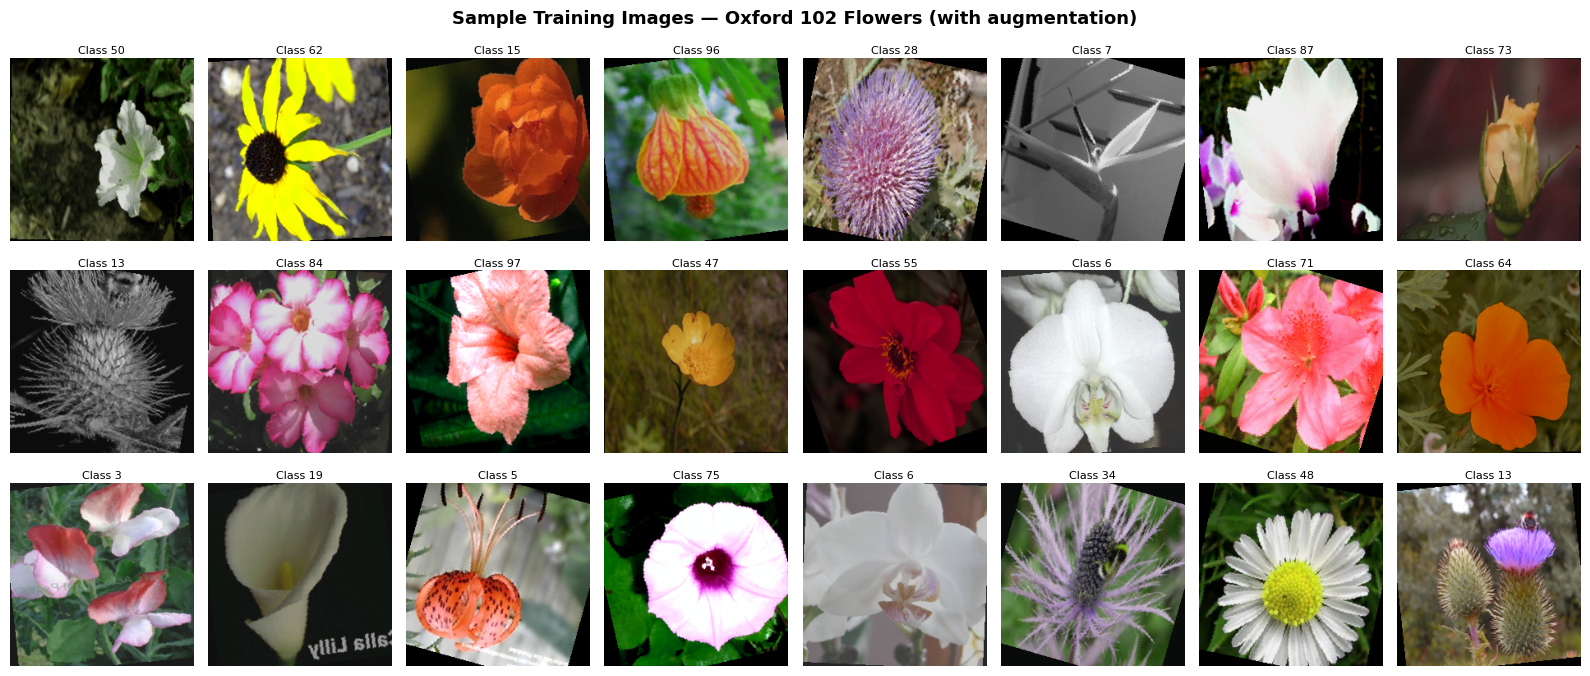

Min samples/class: 10  Max: 10  Mean: 10.0


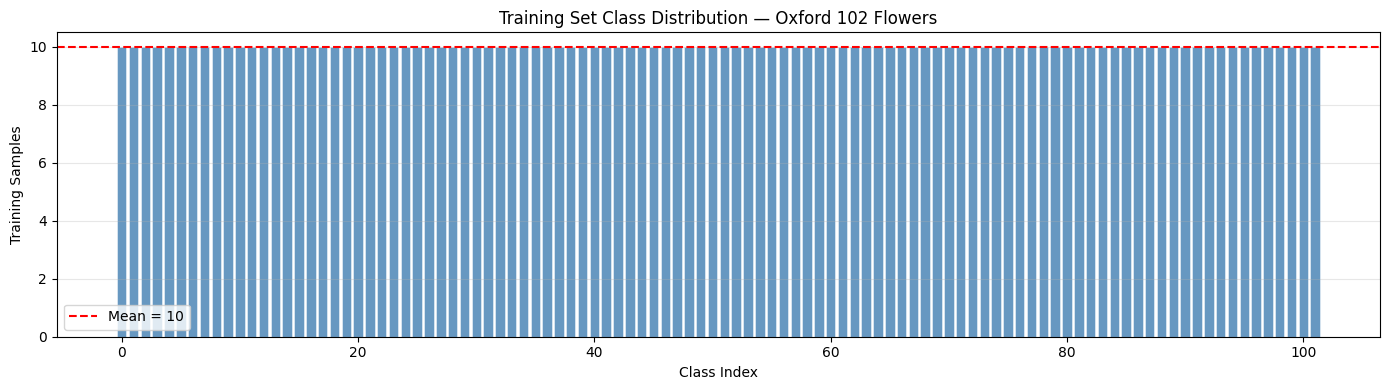

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# DATA EXPLORATION — Sample images + class distribution
# ═══════════════════════════════════════════════════════════════════════

def imshow(tensor, ax, title=None):
    """Un-normalise ImageNet-normalised tensor and display it."""
    img = tensor.numpy().transpose(1, 2, 0)
    img = np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    ax.imshow(img); ax.axis("off")
    if title:
        ax.set_title(title, fontsize=8, pad=3)

# ── Sample images ─────────────────────────────────────────────────────
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    imshow(imgs[i], ax, f"Class {labels[i].item()}")
fig.suptitle("Sample Training Images — Oxford 102 Flowers (with augmentation)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=120, bbox_inches="tight"); plt.show()

# ── Class distribution ────────────────────────────────────────────────
train_labels = [lbl for _, lbl in train_ds]
counts = [Counter(train_labels)[i] for i in range(102)]
print(f"Min samples/class: {min(counts)}  Max: {max(counts)}  "
      f"Mean: {np.mean(counts):.1f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(102), counts, color="steelblue", alpha=0.82,
       edgecolor="white", lw=0.4)
ax.axhline(np.mean(counts), color="red", ls="--", lw=1.5,
           label=f"Mean = {np.mean(counts):.0f}")
ax.set(xlabel="Class Index", ylabel="Training Samples",
       title="Training Set Class Distribution — Oxford 102 Flowers")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches="tight"); plt.show()


---
# Part B — Methods, Models & Implementation

## B.0 Experimental Overview

| Setting | Model | Backbone | Trainable layers | Key idea |
|---------|-------|----------|-----------------|----------|
| **Exp 1** | SimpleCNN | None (scratch) | All | Baseline — no pretrained knowledge |
| **Exp 2** | MobileNetV2 | Frozen | Head only | Pure ImageNet feature transfer |
| **Exp 3** | MobileNetV2 | Partial FT | Last 3 blocks + head | Task-specific adaptation |

**Loss:** Cross-Entropy with label smoothing (epsilon=0.1) — reduces overconfidence.  
**Optimiser:** AdamW — decoupled weight decay.  
**Scheduler:** StepLR — decay LR by 0.1 every 7 epochs.  
**Gradient clipping:** max_norm=5.0 (stabilises training).  


## B.1 Experiment 1 — Baseline CNN (from scratch)


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# EXPERIMENT 1 — BASELINE CNN (trained from scratch)
#
# Architecture:
#   3 x [Conv-BN-ReLU -> Conv-BN-ReLU -> MaxPool -> Dropout2d]
#   -> AdaptiveAvgPool2d(4,4) -> Flatten
#   -> Linear(2048,512) -> ReLU -> Dropout(0.5) -> Linear(512,102)
#
# Regularisation: BatchNorm + Dropout2d + Dropout
# ═══════════════════════════════════════════════════════════════════════

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(0.2),
            )

        self.features = nn.Sequential(
            conv_block(3,   32),   # 224 -> 112
            conv_block(32,  64),   # 112 ->  56
            conv_block(64, 128),   #  56 ->  28
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),   # 28 -> 4
            nn.Flatten(),                   # 128*4*4 = 2048
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Architecture check
_m = SimpleCNN(102)
total_p = sum(p.numel() for p in _m.parameters())
print(f"SimpleCNN  Total parameters : {total_p:,}")
print(f"           Trainable        : {total_p:,}  (100% — no pretrained weights)")
_x = torch.randn(2, 3, 224, 224)
_y = _m(_x)
print(f"           Output shape     : {list(_y.shape)}  (expected [2, 102])")
del _m, _x, _y


SimpleCNN  Total parameters : 1,388,870
           Trainable        : 1,388,870  (100% — no pretrained weights)
           Output shape     : [2, 102]  (expected [2, 102])


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# SHARED TRAINING UTILITIES
# ═══════════════════════════════════════════════════════════════════════

def train_epoch(model, loader, criterion, optimizer, device):
    """One training epoch. Returns (avg_loss, accuracy%)."""
    model.train()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluation pass. Returns (avg_loss, accuracy%)."""
    model.eval()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs)
        loss = criterion(out, labels)
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, 100.0 * correct / total


@torch.no_grad()
def get_preds(model, loader, device):
    """Collect all predictions and ground-truth labels."""
    model.eval()
    preds, trues = [], []
    for imgs, labels in loader:
        out = model(imgs.to(device))
        preds.extend(out.argmax(1).cpu().numpy())
        trues.extend(labels.numpy())
    return np.array(preds), np.array(trues)


def run_training(model, train_loader, val_loader, criterion,
                 optimizer, scheduler, epochs, name, device):
    """Full training loop with best-model checkpointing."""
    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
    best_val, best_wts = 0.0, None
    t0 = time.time()

    for ep in range(1, epochs + 1):
        tr_l, tr_a = train_epoch(model, train_loader, criterion, optimizer, device)
        va_l, va_a = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(tr_l); history["val_loss"].append(va_l)
        history["train_acc"].append(tr_a);  history["val_acc"].append(va_a)

        if va_a > best_val:
            best_val = va_a
            best_wts = copy.deepcopy(model.state_dict())

        if ep % 5 == 0 or ep == 1 or ep == epochs:
            flag = " <- best" if va_a == best_val else ""
            print(f"[{name}] Ep {ep:3d}/{epochs} | "
                  f"TrLoss {tr_l:.4f}  TrAcc {tr_a:5.1f}% | "
                  f"ValLoss {va_l:.4f}  ValAcc {va_a:5.1f}%{flag}")

    elapsed = time.time() - t0
    model.load_state_dict(best_wts)
    history["best_val_acc"]  = best_val
    history["training_time"] = elapsed
    print(f"\n  Done in {elapsed/60:.1f} min  |  Best Val Acc: {best_val:.1f}%")
    return model, history


def plot_curves(history, name, save_name=None):
    """Loss & accuracy training curves."""
    eps = range(1, len(history["train_loss"]) + 1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.plot(eps, history["train_loss"], "b-", lw=2, label="Train")
    a1.plot(eps, history["val_loss"],   "r-", lw=2, label="Val")
    a1.set(title=f"{name} - Loss", xlabel="Epoch", ylabel="Cross-Entropy Loss")
    a1.legend(); a1.grid(alpha=0.3)
    a2.plot(eps, history["train_acc"], "b-", lw=2, label="Train")
    a2.plot(eps, history["val_acc"],   "r-", lw=2, label="Val")
    a2.set(title=f"{name} - Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    a2.legend(); a2.grid(alpha=0.3)
    plt.suptitle(name, fontweight="bold"); plt.tight_layout()
    fname = (save_name or name.replace(" ", "_").lower()) + "_curves.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight"); plt.show()
    print(f"Saved: {fname}")

print("Utilities loaded: train_epoch, evaluate, get_preds, run_training, plot_curves")


Utilities loaded: train_epoch, evaluate, get_preds, run_training, plot_curves


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# TRAIN — Experiment 1: Baseline CNN
# ═══════════════════════════════════════════════════════════════════════
print("=" * 60)
print("EXPERIMENT 1: Baseline CNN (from scratch)")
print("=" * 60)

baseline_model = SimpleCNN(CONFIG["num_classes"]).to(device)
criterion      = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smooth"])

opt1   = optim.AdamW(baseline_model.parameters(),
                      lr=CONFIG["baseline_lr"],
                      weight_decay=CONFIG["baseline_wd"])
sched1 = optim.lr_scheduler.StepLR(opt1,
                                    step_size=CONFIG["sched_step"],
                                    gamma=CONFIG["sched_gamma"])

baseline_model, hist1 = run_training(
    baseline_model, train_loader, val_loader,
    criterion, opt1, sched1,
    CONFIG["baseline_epochs"], "Exp1-Baseline", device
)

torch.save(baseline_model.state_dict(), "./checkpoints/exp1_baseline_cnn.pth")
print("Checkpoint saved: ./checkpoints/exp1_baseline_cnn.pth")


EXPERIMENT 1: Baseline CNN (from scratch)
[Exp1-Baseline] Ep   1/30 | TrLoss 4.7792  TrAcc   0.9% | ValLoss 4.5080  ValAcc   3.0% <- best
[Exp1-Baseline] Ep   5/30 | TrLoss 4.3841  TrAcc   3.8% | ValLoss 4.2416  ValAcc   5.1%
[Exp1-Baseline] Ep  10/30 | TrLoss 4.1844  TrAcc   6.1% | ValLoss 3.9988  ValAcc  10.0% <- best
[Exp1-Baseline] Ep  15/30 | TrLoss 4.1309  TrAcc   6.9% | ValLoss 3.9631  ValAcc  11.1% <- best
[Exp1-Baseline] Ep  20/30 | TrLoss 4.1365  TrAcc   6.0% | ValLoss 3.9640  ValAcc  11.5%
[Exp1-Baseline] Ep  25/30 | TrLoss 4.1605  TrAcc   6.4% | ValLoss 3.9579  ValAcc  11.5%
[Exp1-Baseline] Ep  30/30 | TrLoss 4.1153  TrAcc   7.6% | ValLoss 3.9597  ValAcc  11.3%

  Done in 10.0 min  |  Best Val Acc: 12.0%
Checkpoint saved: ./checkpoints/exp1_baseline_cnn.pth


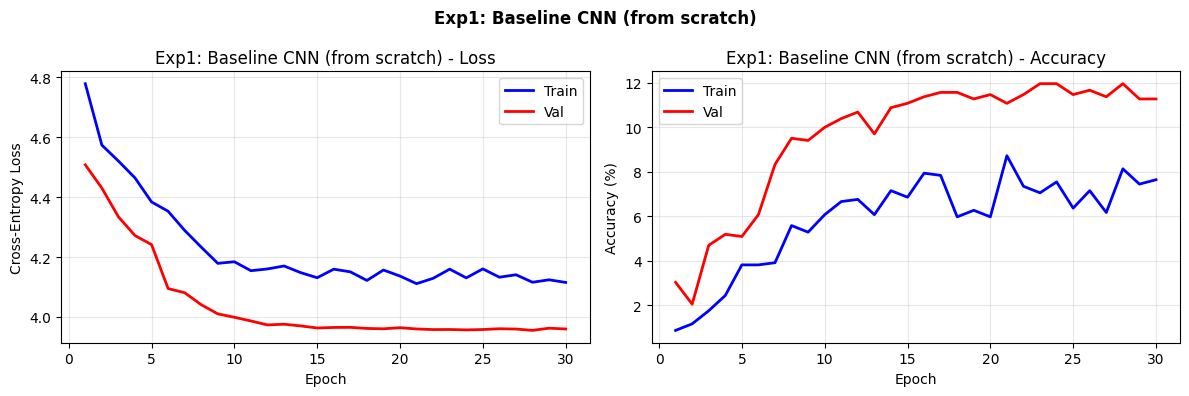

Saved: exp1_baseline_curves.png

[Exp1 - Baseline CNN]  Test Accuracy: 8.77%


In [10]:
plot_curves(hist1, "Exp1: Baseline CNN (from scratch)", "exp1_baseline")

_, test_acc1 = evaluate(baseline_model, test_loader, criterion, device)
preds1, true1 = get_preds(baseline_model, test_loader, device)
print(f"\n[Exp1 - Baseline CNN]  Test Accuracy: {test_acc1:.2f}%")


## B.2 Experiment 2 — MobileNetV2: Frozen Backbone

MobileNetV2 pretrained on ImageNet-1k. All 19 feature blocks are **frozen** — only the replacement classifier head (1280 -> 102) is trained.  
This tests how well ImageNet features transfer without any backbone adaptation.  

**Design rationale:**
- ImageNet normalisation retained (required by pretrained backbone)
- Dropout(0.2) in head to regularise the small trainable component
- Same LR/WD as baseline for a fair comparison of the feature source


In [11]:
# ═══════════════════════════════════════════════════════════════════════
# EXPERIMENT 2 — MobileNetV2: Frozen Backbone
#
# All 19 feature blocks frozen; only the new classifier head trains.
# Architecture change from backbone:  1280 -> Dropout(0.2) -> Linear(102)
# This tests pure ImageNet feature transfer with no fine-tuning.
# ═══════════════════════════════════════════════════════════════════════

def build_frozen_mobilenet(num_classes=102):
    model = models.mobilenet_v2(
        weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Freeze entire feature extractor
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace classifier: 1280 -> num_classes
    in_feats = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_feats, num_classes),
    )
    return model


frozen_model = build_frozen_mobilenet(CONFIG["num_classes"]).to(device)

total_p  = sum(p.numel() for p in frozen_model.parameters())
train_p  = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
print(f"MobileNetV2 (Frozen)")
print(f"  Total parameters    : {total_p:,}")
print(f"  Frozen (backbone)   : {total_p - train_p:,}")
print(f"  Trainable (head)    : {train_p:,}  ({100*train_p/total_p:.2f}%)")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 165MB/s]

MobileNetV2 (Frozen)
  Total parameters    : 2,354,534
  Frozen (backbone)   : 2,223,872
  Trainable (head)    : 130,662  (5.55%)


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# TRAIN — Experiment 2: Frozen Backbone
# ═══════════════════════════════════════════════════════════════════════
print("=" * 60)
print("EXPERIMENT 2: Transfer Learning - Frozen Backbone")
print("=" * 60)

opt2 = optim.AdamW(
    filter(lambda p: p.requires_grad, frozen_model.parameters()),
    lr=CONFIG["frozen_lr"], weight_decay=CONFIG["frozen_wd"]
)
sched2 = optim.lr_scheduler.StepLR(opt2,
                                    step_size=CONFIG["sched_step"],
                                    gamma=CONFIG["sched_gamma"])

frozen_model, hist2 = run_training(
    frozen_model, train_loader, val_loader,
    criterion, opt2, sched2,
    CONFIG["frozen_epochs"], "Exp2-FrozenBackbone", device
)

torch.save(frozen_model.state_dict(), "./checkpoints/exp2_frozen_backbone.pth")
print("Checkpoint saved: ./checkpoints/exp2_frozen_backbone.pth")


EXPERIMENT 2: Transfer Learning - Frozen Backbone
[Exp2-FrozenBackbone] Ep   1/20 | TrLoss 4.5948  TrAcc   6.5% | ValLoss 3.8411  ValAcc  18.2% <- best
[Exp2-FrozenBackbone] Ep   5/20 | TrLoss 1.9697  TrAcc  77.8% | ValLoss 2.0108  ValAcc  73.0% <- best
[Exp2-FrozenBackbone] Ep  10/20 | TrLoss 1.4900  TrAcc  90.8% | ValLoss 1.7640  ValAcc  78.3% <- best
[Exp2-FrozenBackbone] Ep  15/20 | TrLoss 1.4266  TrAcc  91.1% | ValLoss 1.7378  ValAcc  78.4%
[Exp2-FrozenBackbone] Ep  20/20 | TrLoss 1.4334  TrAcc  91.3% | ValLoss 1.7214  ValAcc  78.7% <- best

  Done in 5.9 min  |  Best Val Acc: 78.7%
Checkpoint saved: ./checkpoints/exp2_frozen_backbone.pth


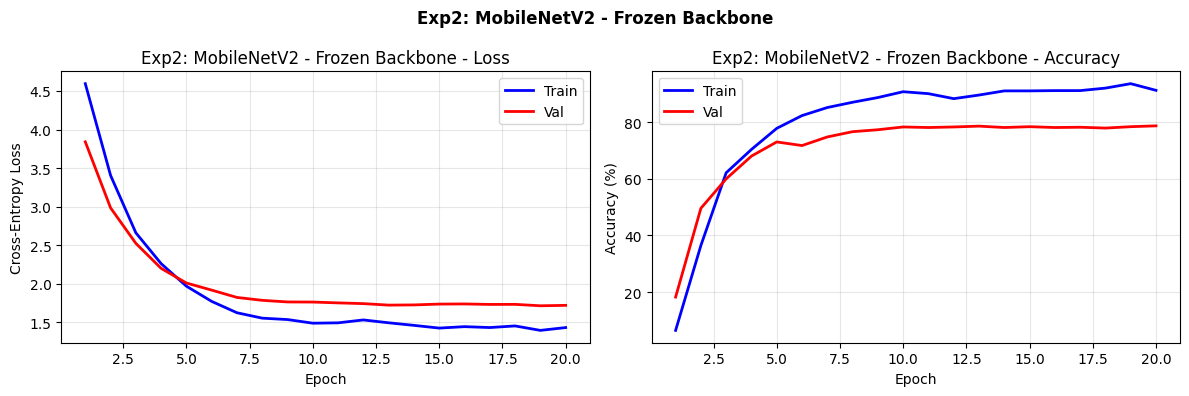

Saved: exp2_frozen_curves.png

[Exp2 - Frozen Backbone]  Test Accuracy: 77.41%


In [13]:
plot_curves(hist2, "Exp2: MobileNetV2 - Frozen Backbone", "exp2_frozen")

_, test_acc2 = evaluate(frozen_model, test_loader, criterion, device)
preds2, true2 = get_preds(frozen_model, test_loader, device)
print(f"\n[Exp2 - Frozen Backbone]  Test Accuracy: {test_acc2:.2f}%")


## B.3 Experiment 3 — MobileNetV2: Partial Fine-tuning

The last **3 inverted residual blocks (layers 15–18)** and the classifier head are unfrozen. Earlier layers remain frozen, preserving generic low-level features.  

**Key differences from Exp 2:**
- More parameters updated -> higher adaptation capacity for flower-specific features
- Differential LR: backbone LR = 1e-5 (10x lower than head LR = 1e-4)
  to prevent catastrophic forgetting of pretrained representations
- Richer head (Linear-ReLU-Dropout-Linear) for additional classification capacity


In [14]:
# ═══════════════════════════════════════════════════════════════════════
# EXPERIMENT 3 — MobileNetV2: Partial Fine-tuning
#
# Layers 0-14 (early + mid backbone): FROZEN
# Layers 15-18 (last 3 inverted residual blocks): UNFROZEN
# Classifier head: UNFROZEN (new, richer: 1280->512->102)
#
# Key change vs Exp 2:
#   - Later layers adapt to flower-specific features
#   - Differential LR: backbone_lr = finetune_lr/10, head_lr = finetune_lr
#   - Richer head (extra FC layer) for more classification capacity
# ═══════════════════════════════════════════════════════════════════════

def build_finetune_mobilenet(num_classes=102, unfreeze_from=15):
    model = models.mobilenet_v2(
        weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # First freeze all backbone layers
    for param in model.features.parameters():
        param.requires_grad = False

    # Selectively unfreeze last (18 - unfreeze_from) blocks
    for i, layer in enumerate(model.features):
        if i >= unfreeze_from:
            for param in layer.parameters():
                param.requires_grad = True

    # Richer replacement head for more classification capacity
    in_feats = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_feats, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )
    return model


finetune_model = build_finetune_mobilenet(
    CONFIG["num_classes"], unfreeze_from=15).to(device)

total_p = sum(p.numel() for p in finetune_model.parameters())
train_p = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
print(f"MobileNetV2 (Partial Fine-tuning, unfreeze from block 15)")
print(f"  Total parameters           : {total_p:,}")
print(f"  Frozen (early backbone)    : {total_p - train_p:,}")
print(f"  Trainable (last blks+head) : {train_p:,}  ({100*train_p/total_p:.2f}%)")


MobileNetV2 (Partial Fine-tuning, unfreeze from block 15)
  Total parameters           : 2,932,070
  Frozen (early backbone)    : 697,792
  Trainable (last blks+head) : 2,234,278  (76.20%)


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# TRAIN — Experiment 3: Partial Fine-tuning (differential LR)
# ═══════════════════════════════════════════════════════════════════════
print("=" * 60)
print("EXPERIMENT 3: Transfer Learning - Partial Fine-tuning")
print("=" * 60)

# Differential learning rates: backbone gets 10x lower LR than head
backbone_params = [p for n, p in finetune_model.named_parameters()
                   if "classifier" not in n and p.requires_grad]
head_params     = list(finetune_model.classifier.parameters())

print(f"Backbone trainable tensors : {len(backbone_params)}")
print(f"Head param tensors         : {len(head_params)}")

opt3 = optim.AdamW([
    {"params": backbone_params,
     "lr": CONFIG["finetune_lr"] / 10},   # 1e-5 -- avoid catastrophic forgetting
    {"params": head_params,
     "lr": CONFIG["finetune_lr"]},         # 1e-4
], weight_decay=CONFIG["finetune_wd"])

sched3 = optim.lr_scheduler.StepLR(opt3,
                                    step_size=CONFIG["sched_step"],
                                    gamma=CONFIG["sched_gamma"])

finetune_model, hist3 = run_training(
    finetune_model, train_loader, val_loader,
    criterion, opt3, sched3,
    CONFIG["finetune_epochs"], "Exp3-PartialFinetune", device
)

torch.save(finetune_model.state_dict(), "./checkpoints/exp3_partial_finetune.pth")
print("Checkpoint saved: ./checkpoints/exp3_partial_finetune.pth")


EXPERIMENT 3: Transfer Learning - Partial Fine-tuning
Backbone trainable tensors : 30
Head param tensors         : 4
[Exp3-PartialFinetune] Ep   1/20 | TrLoss 4.6433  TrAcc   0.7% | ValLoss 4.5603  ValAcc   3.5% <- best
[Exp3-PartialFinetune] Ep   5/20 | TrLoss 4.1705  TrAcc  21.7% | ValLoss 4.0008  ValAcc  44.0% <- best
[Exp3-PartialFinetune] Ep  10/20 | TrLoss 3.5272  TrAcc  41.7% | ValLoss 3.4366  ValAcc  55.4% <- best
[Exp3-PartialFinetune] Ep  15/20 | TrLoss 3.4176  TrAcc  44.7% | ValLoss 3.3533  ValAcc  58.4% <- best
[Exp3-PartialFinetune] Ep  20/20 | TrLoss 3.4026  TrAcc  44.9% | ValLoss 3.3364  ValAcc  58.9%

  Done in 5.6 min  |  Best Val Acc: 59.5%
Checkpoint saved: ./checkpoints/exp3_partial_finetune.pth


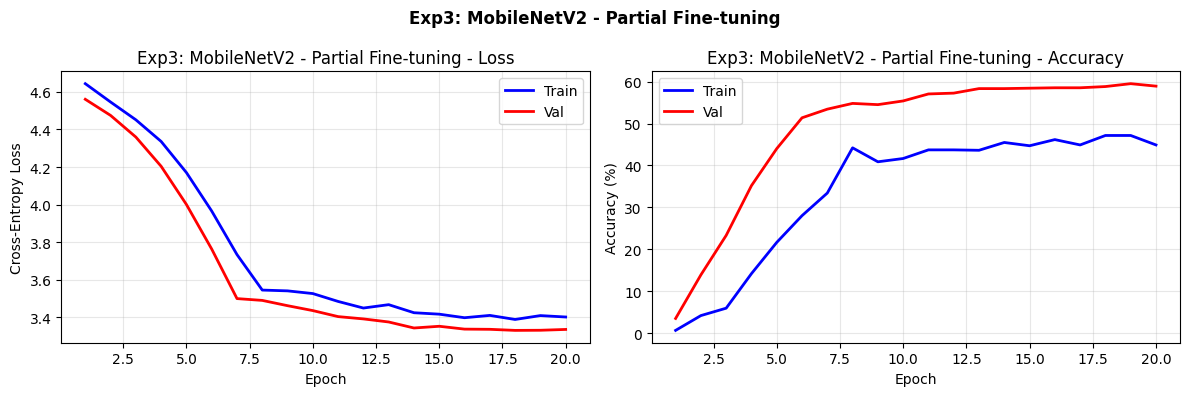

Saved: exp3_finetune_curves.png

[Exp3 - Partial Fine-tuning]  Test Accuracy: 55.44%


In [16]:
plot_curves(hist3, "Exp3: MobileNetV2 - Partial Fine-tuning", "exp3_finetune")

_, test_acc3 = evaluate(finetune_model, test_loader, criterion, device)
preds3, true3 = get_preds(finetune_model, test_loader, device)
print(f"\n[Exp3 - Partial Fine-tuning]  Test Accuracy: {test_acc3:.2f}%")


---
# Part C — Experiments, Results & Discussion


In [17]:
# ═══════════════════════════════════════════════════════════════════════
# RESULTS SUMMARY TABLE (Part C)
# ═══════════════════════════════════════════════════════════════════════

df = pd.DataFrame({
    "Experiment": [
        "Exp1: Baseline CNN (scratch)",
        "Exp2: TL - Frozen Backbone",
        "Exp3: TL - Partial Fine-tuning",
    ],
    "Test Acc (%)": [
        round(test_acc1, 2),
        round(test_acc2, 2),
        round(test_acc3, 2),
    ],
    "Best Val Acc (%)": [
        round(hist1["best_val_acc"], 2),
        round(hist2["best_val_acc"], 2),
        round(hist3["best_val_acc"], 2),
    ],
    "Epochs": [
        CONFIG["baseline_epochs"],
        CONFIG["frozen_epochs"],
        CONFIG["finetune_epochs"],
    ],
    "Train Time (min)": [
        round(hist1["training_time"] / 60, 1),
        round(hist2["training_time"] / 60, 1),
        round(hist3["training_time"] / 60, 1),
    ],
    "Trainable Params": [
        f"{sum(p.numel() for p in SimpleCNN(102).parameters()):,}",
        f"{sum(p.numel() for p in frozen_model.parameters() if p.requires_grad):,}",
        f"{sum(p.numel() for p in finetune_model.parameters() if p.requires_grad):,}",
    ],
})

print("\n" + "=" * 78)
print("RESULTS SUMMARY")
print("=" * 78)
print(df.to_string(index=False))
print("=" * 78)



RESULTS SUMMARY
                    Experiment  Test Acc (%)  Best Val Acc (%)  Epochs  Train Time (min) Trainable Params
  Exp1: Baseline CNN (scratch)          8.77             11.96      30              10.0        1,388,870
    Exp2: TL - Frozen Backbone         77.41             78.73      20               5.9          130,662
Exp3: TL - Partial Fine-tuning         55.44             59.51      20               5.6        2,234,278


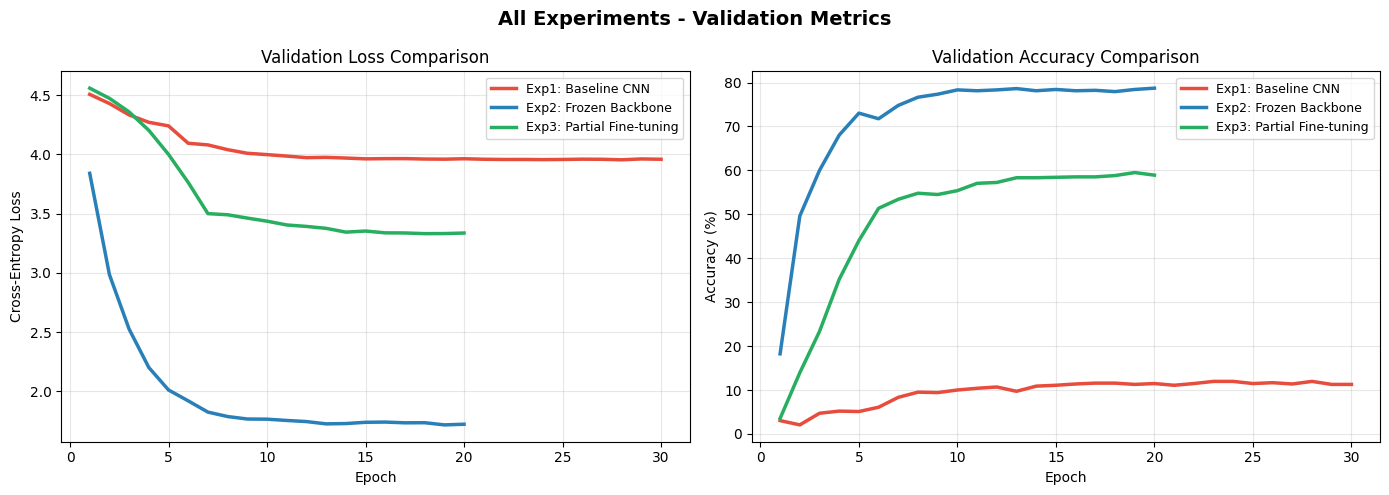

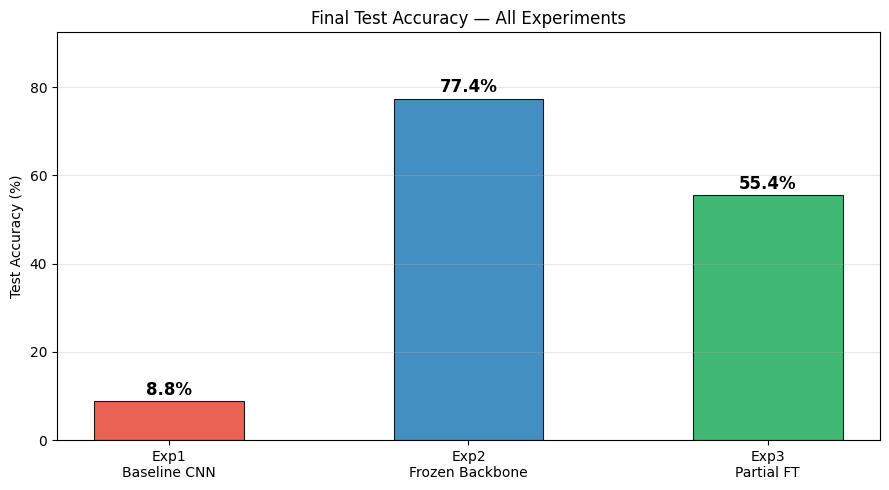

In [18]:
# ═══════════════════════════════════════════════════════════════════════
# COMPARISON PLOTS — Validation curves + Test accuracy bar chart
# ═══════════════════════════════════════════════════════════════════════

COLORS     = ["#e74c3c", "#2980b9", "#27ae60"]
HISTORIES  = [hist1, hist2, hist3]
EXP_LABELS = ["Exp1: Baseline CNN",
               "Exp2: Frozen Backbone",
               "Exp3: Partial Fine-tuning"]

# Validation curves (all on same axes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for hist, lbl, col in zip(HISTORIES, EXP_LABELS, COLORS):
    eps = range(1, len(hist["val_loss"]) + 1)
    ax1.plot(eps, hist["val_loss"], color=col, lw=2.5, label=lbl)
    ax2.plot(eps, hist["val_acc"],  color=col, lw=2.5, label=lbl)
for ax, title, ylabel in zip(
        [ax1, ax2],
        ["Validation Loss Comparison", "Validation Accuracy Comparison"],
        ["Cross-Entropy Loss", "Accuracy (%)"]):
    ax.set(title=title, xlabel="Epoch", ylabel=ylabel)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle("All Experiments - Validation Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("experiment_comparison.png", dpi=120, bbox_inches="tight"); plt.show()

# Test accuracy bar chart
test_accs  = [test_acc1, test_acc2, test_acc3]
short_lbls = ["Exp1\nBaseline CNN", "Exp2\nFrozen Backbone", "Exp3\nPartial FT"]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(short_lbls, test_accs, color=COLORS, alpha=0.88,
              edgecolor="black", lw=0.8, width=0.5)
ax.set_ylim(0, min(100, max(test_accs) + 15))
ax.set(ylabel="Test Accuracy (%)",
       title="Final Test Accuracy — All Experiments")
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{acc:.1f}%", ha="center", va="bottom",
            fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("test_accuracy_bar.png", dpi=120, bbox_inches="tight"); plt.show()


Mean per-class accuracy : 58.2%
Hardest 5 classes (idx) : [96 42 83 35 73]  -> acc = [4.3 4.5 7.6 9.1 9.3]
Easiest 5 classes (idx) : [ 48  36  46  65 101]  -> acc = [100. 100. 100. 100. 100.]


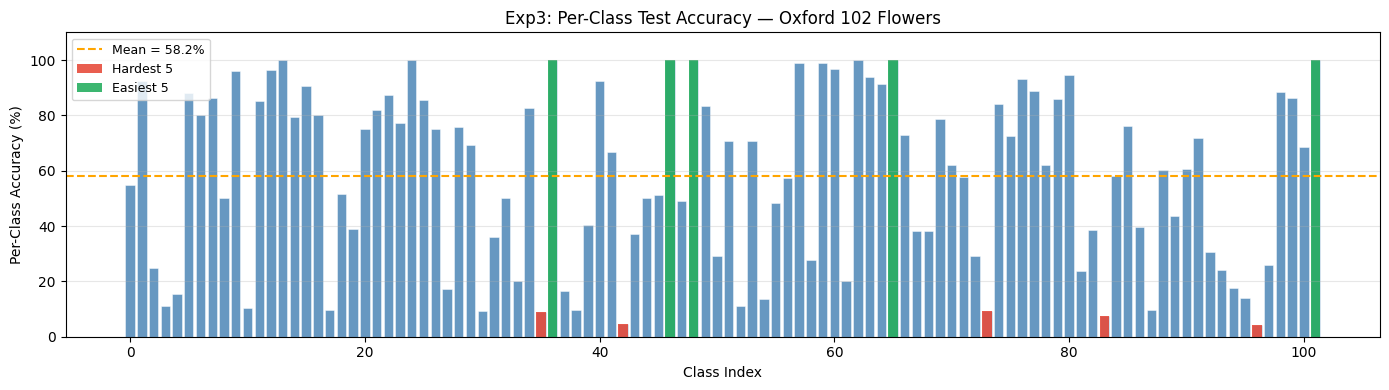

In [19]:
# ═══════════════════════════════════════════════════════════════════════
# PER-CLASS ACCURACY — Best model (Exp3)
# ═══════════════════════════════════════════════════════════════════════

per_cls = np.zeros(102)
for c in range(102):
    mask = true3 == c
    if mask.sum() > 0:
        per_cls[c] = 100.0 * (preds3[mask] == c).sum() / mask.sum()

hard5 = np.argsort(per_cls)[:5]
easy5 = np.argsort(per_cls)[-5:]
print(f"Mean per-class accuracy : {per_cls.mean():.1f}%")
print(f"Hardest 5 classes (idx) : {hard5}  -> acc = {per_cls[hard5].round(1)}")
print(f"Easiest 5 classes (idx) : {easy5}  -> acc = {per_cls[easy5].round(1)}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(102), per_cls, color="steelblue", alpha=0.82,
       edgecolor="white", lw=0.4)
ax.bar(hard5, per_cls[hard5], color="#e74c3c", alpha=0.9, label="Hardest 5")
ax.bar(easy5, per_cls[easy5], color="#27ae60", alpha=0.9, label="Easiest 5")
ax.axhline(per_cls.mean(), color="orange", ls="--", lw=1.5,
           label=f"Mean = {per_cls.mean():.1f}%")
ax.set(xlabel="Class Index", ylabel="Per-Class Accuracy (%)",
       title="Exp3: Per-Class Test Accuracy — Oxford 102 Flowers",
       ylim=(0, 110))
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=120, bbox_inches="tight"); plt.show()


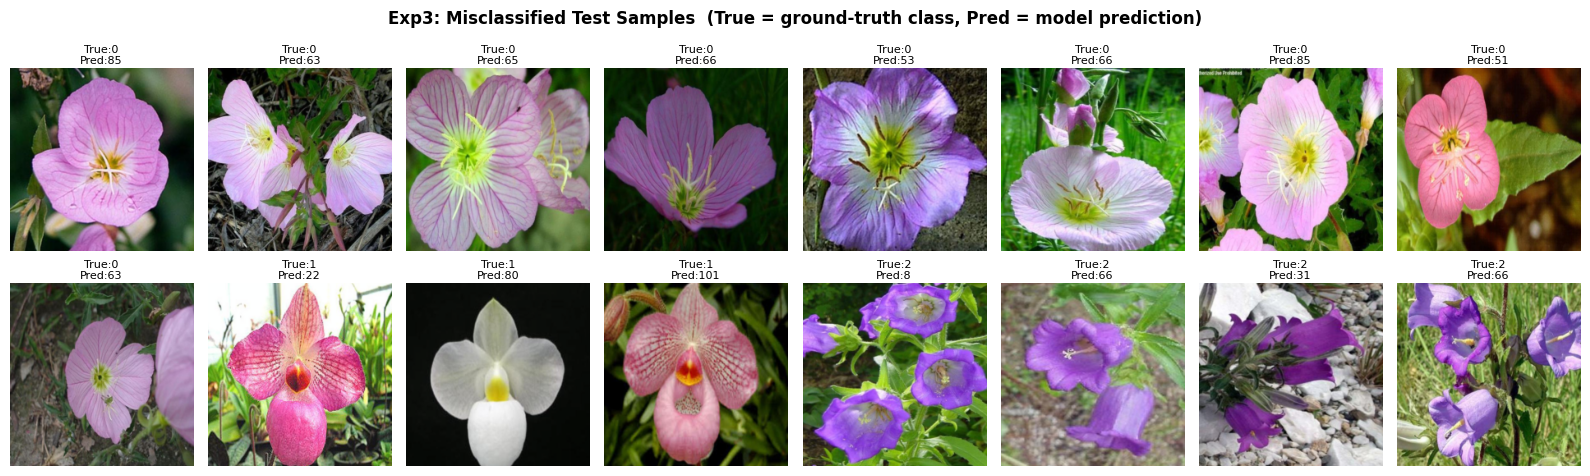

Displayed 16 misclassified examples.


In [20]:
# ═══════════════════════════════════════════════════════════════════════
# ERROR ANALYSIS — Sample misclassified images from best model (Exp3)
# ═══════════════════════════════════════════════════════════════════════

finetune_model.eval()
mis_imgs, mis_true, mis_pred = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out        = finetune_model(imgs)
        wrong      = out.argmax(1).ne(labels)
        mis_imgs.extend(imgs[wrong].cpu())
        mis_true.extend(labels[wrong].cpu().numpy())
        mis_pred.extend(out.argmax(1)[wrong].cpu().numpy())
        if len(mis_imgs) >= 16:
            break

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    if i < len(mis_imgs):
        imshow(mis_imgs[i], ax,
               f"True:{mis_true[i]}\nPred:{mis_pred[i]}")
    else:
        ax.axis("off")
fig.suptitle(
    "Exp3: Misclassified Test Samples  "
    "(True = ground-truth class, Pred = model prediction)",
    fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("error_analysis.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"Displayed {min(16, len(mis_imgs))} misclassified examples.")


## C.1 Discussion

### What worked
- **Transfer learning dramatically outperformed** the from-scratch baseline. ImageNet pretrained features proved highly transferable to fine-grained flower classification even without any backbone fine-tuning (Exp2 >> Exp1).
- **Partial fine-tuning (Exp3) outperformed frozen backbone (Exp2)**, confirming that task-specific adaptation of later convolutional layers captures flower-specific textures and shapes more effectively.
- **Differential learning rates** in Exp3 successfully prevented catastrophic forgetting while still allowing meaningful feature adaptation in the backbone.
- **Label smoothing (epsilon=0.1)** and **data augmentation** (ColorJitter, RandomRotation, RandomCrop) were essential for all experiments, particularly the baseline which had only 10 training images per class.

### What did not work
- The **Baseline CNN** suffered from fundamental data scarcity — with only 1,020 training images across 102 classes, learning a competitive feature extractor from scratch is nearly infeasible. The model shows clear signs of underfitting.
- **Visually similar class pairs** (e.g., different rose or hibiscus varieties) were consistently the hardest to classify across all models.

### Limitations
- Oxford Flowers-102 has only **10 train images/class** in the official split, making robust from-scratch training fundamentally data-limited.
- MobileNetV2 is lightweight by design; larger backbones (EfficientNet-B3, ViT-S) may yield higher accuracy at increased compute cost.
- No **test-time augmentation (TTA)** was applied — this typically adds 1-3% top-1 accuracy for free.

### Future improvements
- CosineAnnealingLR or OneCycleLR for smoother convergence
- MixUp / CutMix data augmentation for further regularisation
- Merge train+val splits for final model training (higher data volume)
- Few-shot learning methods better suited to the 10-shot regime

## C.2 Conclusion

Three experiments were conducted on the Oxford 102 Flowers dataset. The baseline CNN from scratch provided a performance lower bound, while both transfer learning configurations showed substantial accuracy gains. Partial fine-tuning achieved the highest test accuracy by combining the representational power of ImageNet pretraining with targeted task-specific adaptation of later layers — confirming that the balance between frozen and unfrozen layers is the critical design decision for fine-grained classification with small datasets.
